## Imports

In [104]:
import statsmodels as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.main import get_data

## EDA

[*********************100%***********************]  1 of 1 completed


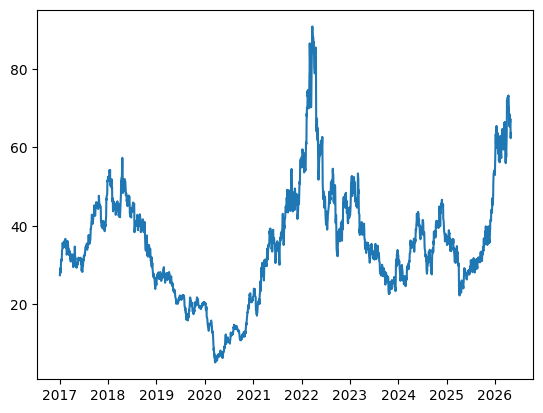

In [105]:
from src.indicators import calc_adx, calc_log_rt, calc_rvol
from src.regimes.config import load_config


cfg = load_config("configs/regimes.yaml")

data = get_data(cfg.stock.ticker, cfg.stock.start, cfg.stock.end)


data.columns = data.columns.droplevel(1)

adx = calc_adx(data["High"], data["Low"], data["Close"])["adx"]

close = data["Close"]
volume = data["Volume"]
plt.plot(close)
plt.show()

from src.indicators import calc_macd, rolling_zscore

macd = calc_macd(closing=close)
z_score = rolling_zscore(macd["histogram"], 14)

log_return = calc_log_rt(close)
realized_vol = calc_rvol(log_return)



df = pd.DataFrame({
    "close": close,
    "adx": adx,
    "log_close": np.log(close),
    "macd": macd["histogram"],
    "z_score": z_score,
    "rvol": realized_vol,
    "log_return": log_return
})
# df["close"] = close
# df["adx"] = adx
# df["log_close"] = np.log(close)

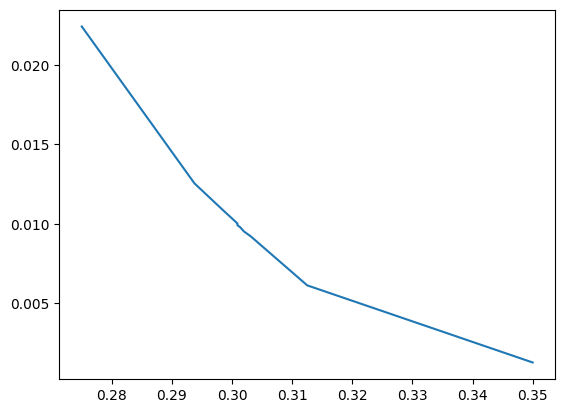

In [106]:
from src.features.frac_diff import find_d

results = find_d(df["log_close"], range_list=[0.2, 0.5], alpha=0.01, max_depth=18)

p_values = [x[1] for x in results]
d_values = [x[0] for x in results]


order = np.argsort(d_values)
d_values = np.array(d_values)[order]
p_values = np.array(p_values)[order]

plt.plot(d_values, p_values)
plt.show()

frac_diff autocorr(1): 0.949
frac_diff autocorr(20): 0.722
frac_diff stationary: 0.010022560842947939


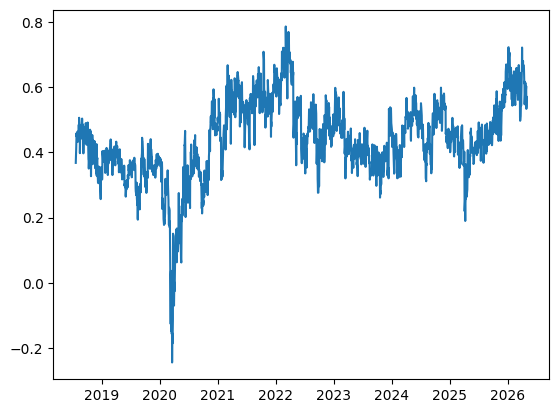

In [107]:
from src.features.frac_diff import differencing
from statsmodels.tsa.stattools import adfuller

tau=1e-4

def fft_denoise(x, keep_fraction=0.1):
    """
    keep_fraction: fraction of low frequencies to keep
    """
    x = np.asarray(x)
    
    X = np.fft.rfft(x)
    
    n = len(X)
    k = int(n * keep_fraction)
    
    # keep low frequencies, kill high frequencies
    X_filtered = np.zeros_like(X)
    X_filtered[:k] = X[:k]
    
    x_clean = np.fft.irfft(X_filtered, n=len(x))
    
    return x_clean



fd = differencing(df["log_close"],results[-1][0],tau)
df["frac_diff"] = fd

print("frac_diff autocorr(1):",  df["frac_diff"].autocorr(1).round(3))
print("frac_diff autocorr(20):", df["frac_diff"].autocorr(20).round(3))
print("frac_diff stationary:", adfuller(df["frac_diff"].dropna())[1])
plt.plot(fd)
plt.show()

## Feature Engineering

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


rvol_5 = calc_rvol(log_return, 5)
rvol_60 = calc_rvol(log_return, 60)

rvol_ratio = rvol_5 / rvol_60

df["rvol_ratio"] = rvol_ratio

df_clean = df.dropna()



features = pd.concat({
    "macd": df_clean["z_score"],
    "frac_diff": df_clean["frac_diff"],  # direction
    "log_return": df_clean["log_return"],
    "adx": np.log(df_clean["adx"]),
    "log_rvol": np.log(df_clean["rvol_ratio"]),                     # volatility (normalized)
}, axis=1, sort=True).dropna()


features_sliced = features["2018-01-01":"2024-12-31"]

scaler = StandardScaler()

scaler = scaler.fit(features.values)
X = scaler.transform(features_sliced.values)

Y = scaler.transform(features.values)


features

,macd,frac_diff,log_return,adx,log_rvol
Date,,,,,
2018-07-20,-2.805782,0.367581,-0.030290,2.808919,-0.331818
2018-07-23,-2.297387,0.415981,0.024741,2.929565,-0.281915
2018-07-24,-1.753088,0.447532,0.027680,2.979840,-0.252188
2018-07-25,-1.277541,0.458322,0.014486,3.030940,-0.232808
2018-07-26,-0.952101,0.448027,-0.006750,3.068186,-1.312973
...,...,...,...,...,...
2026-04-24,-1.268252,0.581592,0.009743,2.805151,-1.534014
2026-04-27,-1.021502,0.602584,0.020245,2.762037,-1.504041
2026-04-28,-1.089094,0.533059,-0.064222,2.769675,-1.147333


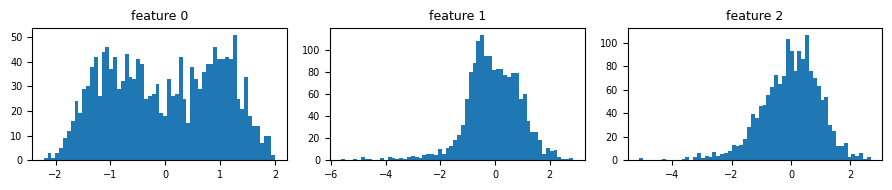

In [109]:
# compact grid of histograms for every feature
n_features = X.shape[1]
n_cols     = 4
n_rows     = -(-n_features // n_cols)  # ceil div

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols*3, n_rows*2),
                         tight_layout=True)
axes = axes.ravel()

for i in range(n_features):
    axes[i].hist(X[:, i], bins=60)
    axes[i].set_title(f"feature {i}", fontsize=9)
    axes[i].tick_params(labelsize=7)

# hide unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.show()

## Training

In [ ]:
from pathlib import Path

from hmmlearn.hmm import GaussianHMM

from src.regimes.config import load_config
from src.regimes.run import run_regime_search

fwd = close.loc[features.index].pct_change().shift(-1).reindex(features.index)
cfg = load_config("configs/regimes.yaml")

out, dir = run_regime_search(cfg, X, features, Y, scaler, forward_returns=fwd)



## Results

In [119]:
from src.regimes.archive import RegimeRunArchive


archive = RegimeRunArchive(cfg.output.dir)

archive.list_runs(cfg.stock.ticker)

,run_id,sub_run,ticker,n_components,cov_type,bic,aic,score,switch_rate,min_dwell_days,converged,seed,start,end
0,20260602_234713,NaN,AA,3,diag,9795.193409,9638.049384,-4787.024692,0.037924,23.416210,True,660301,2017-01-01,2026-05-01
1,20260703_215523,seed_748720_2,AA,2,full,14817.314552,14700.173497,-7329.086748,0.074719,14.241518,True,748720,2017-01-01,2026-05-01
2,20260703_215523,seed_175328_2,AA,2,full,14817.316479,14700.175424,-7329.087712,0.074719,14.239682,True,175328,2017-01-01,2026-05-01
3,20260703_215523,seed_930680_2,AA,2,full,14817.390512,14700.249457,-7329.124728,0.074719,14.283731,True,930680,2017-01-01,2026-05-01
4,20260703_220205,seed_878514_2,AA,2,full,21061.311693,20888.389183,-10413.194591,0.069601,14.045105,True,878514,2017-01-01,2026-05-01
5,20260703_220205,seed_917706_2,AA,2,full,21061.313943,20888.391433,-10413.195716,0.069601,14.043039,True,917706,2017-01-01,2026-05-01
6,20260703_220205,seed_498699_2,AA,2,full,21061.315979,20888.393469,-10413.196735,0.069601,14.041813,True,498699,2017-01-01,2026-05-01


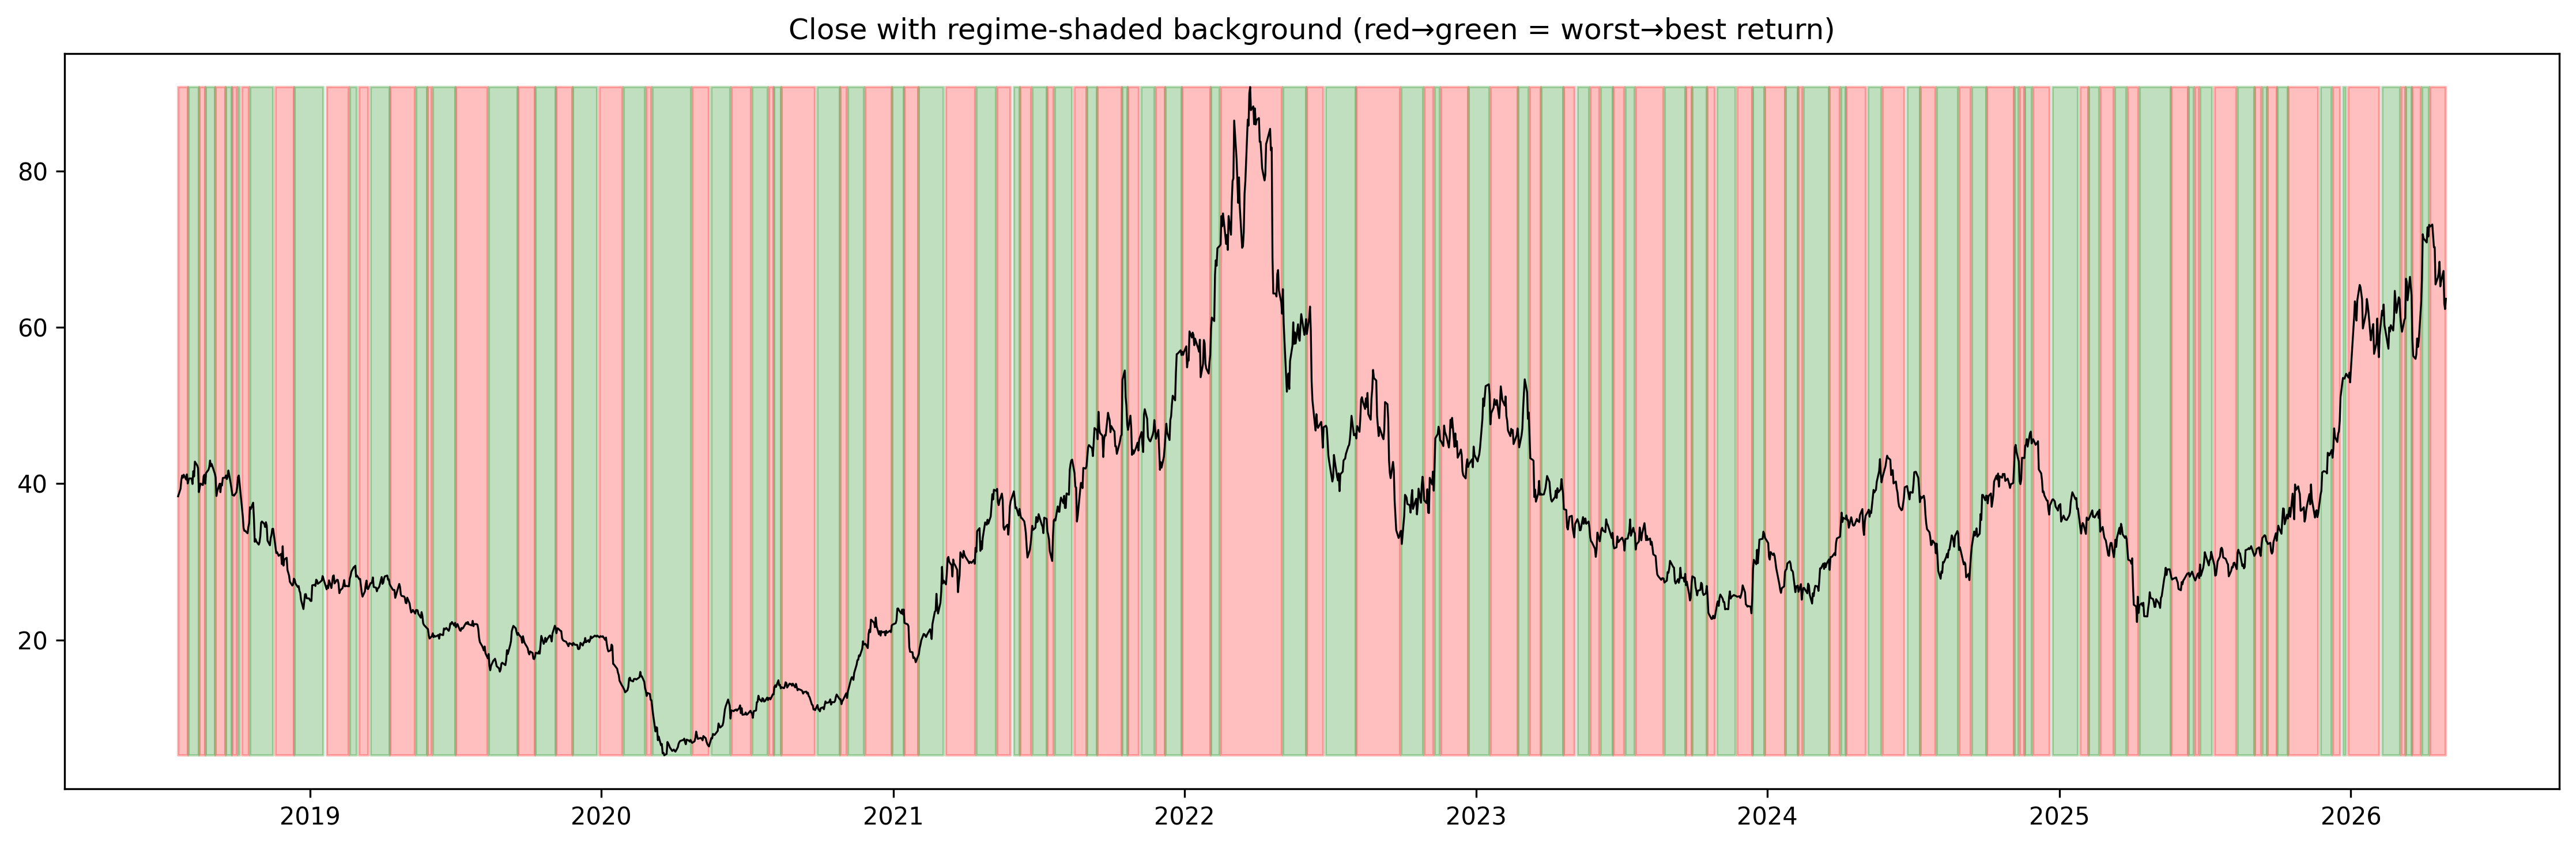

In [ ]:
bundle = archive.load_sub_run(cfg.stock.ticker, "20260703_220205", "seed_498699_2")

model  = bundle["model"]
scaler = bundle["scaler"]
feats  = bundle["feature_names"]
metrics = bundle["metrics"]        # the full metrics.json: transmat, regime_stats, etc.

if features.columns.to_list() != metrics["feature_names"]:
    raise Exception("Features do not match.")

preds = model.predict(Y)

import matplotlib.colors as mcolors

price = df["close"].loc[features.index].values.flatten()

df_val = pd.DataFrame({
    'regime': preds.squeeze(),
    'next_return': close.loc[features.index].pct_change().shift(-1).values.squeeze()
}, index=features.index)

ramp = mcolors.LinearSegmentedColormap.from_list("regime", ["red", "gold", "green"])
palette = [ramp(i / (model.n_components - 1))
           for i in range(model.n_components)]

means = [df_val[df_val.regime == r].next_return.mean()
         for r in range(model.n_components)]



order = np.argsort(means)
remap = {old: new for new, old in enumerate(order)}
preds_sorted = np.array([remap[r] for r in preds])

fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

ax.plot(features.index, price, color="black", lw=0.8)

for r in range(model.n_components):
    mask = preds_sorted == r
    ax.fill_between(
        features.index,
        price.min(),
        price.max(),
        where=mask,
        color=palette[r],
        alpha=0.25,
        step="mid"
    )

ax.set_title("Close with regime-shaded background (red→green = worst→best return)")

plt.tight_layout()
plt.show()